<a href="https://colab.research.google.com/github/Suthirtha2004/ml-from-scratch/blob/main/Decision_Tree_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
!pip install xgboost --quiet
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

RANDOM_STATE = 55

In [ ]:
# Load the dataset
df = pd.read_csv("/content/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
cat_vars = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

In [ ]:
df = pd.get_dummies(data = df,prefix=cat_vars,columns=cat_vars)

In [ ]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,True,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,False,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,True,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,False,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,False,True,False,False,True,False,True,False,False,False,True


In [ ]:
var = [x for x in df.columns if x not in 'HeartDisease']

In [ ]:
print(len(var))

20


In [ ]:
x_train , x_test , y_train , y_test  = train_test_split(df[var],df['HeartDisease'],train_size=0.8,random_state=RANDOM_STATE)

In [ ]:
print(f"Train Samples : {len(x_train)} \ntest samples : {len(x_test)}")
print(f"Target Proportion : {sum(y_train)/len(y_train):.4f}")

Train Samples : 734 
test samples : 184
Target Proportion : 0.5518


In [ ]:
min_samples_split_list = [2,10,30,50,100,200,300,700]
max_depth_list = [1,2,3,4,8,16,32,64,None]

#min samples - minimum samples required to split an internal node
# max_depth - maximum depth of the tree

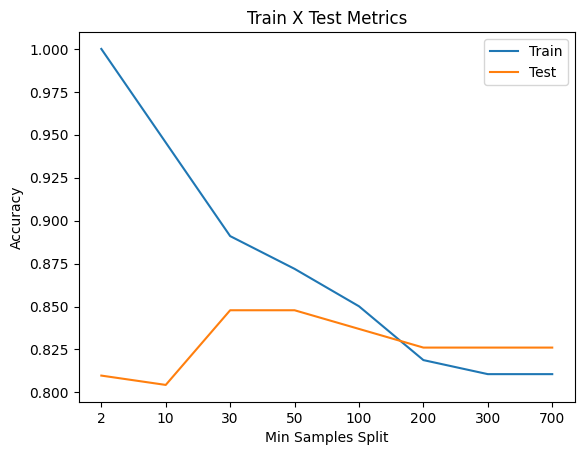

In [ ]:
# Tuning the min samples first

accuracy_list_train= []
accuracy_list_test = []

for min_samples_split in min_samples_split_list:
  # Fitting the model at the same time we can define it
  model = DecisionTreeClassifier(min_samples_split=min_samples_split,random_state=RANDOM_STATE).fit(x_train,y_train)

  predictions_train = model.predict(x_train)
  predictions_test = model.predict(x_test)
  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_test = accuracy_score(predictions_test,y_test)
  accuracy_list_train.append(accuracy_train)
  accuracy_list_test.append(accuracy_test)


plt.title("Train X Test Metrics")
plt.xlabel('Min Samples Split')
plt.ylabel('Accuracy')
plt.xticks(ticks = range(len(min_samples_split_list)),labels = min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

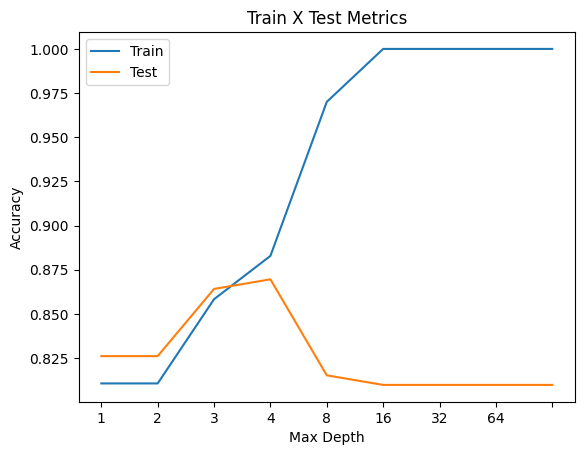

In [ ]:
# Tuning the min samples first

accuracy_list_train= []
accuracy_list_test = []

for max_depth in max_depth_list:
  # Fitting the model at the same time we can define it
  model = DecisionTreeClassifier(max_depth = max_depth,random_state=RANDOM_STATE).fit(x_train,y_train)

  predictions_train = model.predict(x_train)
  predictions_test = model.predict(x_test)
  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_test = accuracy_score(predictions_test,y_test)
  accuracy_list_train.append(accuracy_train)
  accuracy_list_test.append(accuracy_test)


plt.title("Train X Test Metrics")
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(ticks = range(len(max_depth_list)),labels = max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

In [ ]:
# using tuned parameters

decision_tree_model = DecisionTreeClassifier(min_samples_split=50,max_depth = 3,random_state=RANDOM_STATE).fit(x_train,y_train)

print(f"Metrics train : \n\tAccuracy Score : {accuracy_score(decision_tree_model.predict(x_train),y_train):.4f} \nMetrics Test : \n\tAccuracy Score : {accuracy_score(decision_tree_model.predict(x_test),y_test):.4f}")

Metrics train : 
	Accuracy Score : 0.8583 
Metrics Test : 
	Accuracy Score : 0.8641


In [ ]:
# Random Forest
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]


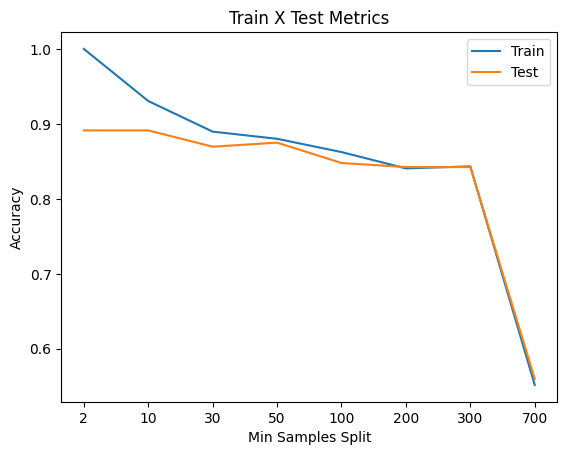

In [ ]:
# Tuning the min samples first

accuracy_list_train= []
accuracy_list_test = []

for min_samples_split in min_samples_split_list:
  # Fitting the model at the same time we can define it
  model = RandomForestClassifier(min_samples_split= min_samples_split,random_state=RANDOM_STATE).fit(x_train,y_train)

  predictions_train = model.predict(x_train)
  predictions_test = model.predict(x_test)
  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_test = accuracy_score(predictions_test,y_test)
  accuracy_list_train.append(accuracy_train)
  accuracy_list_test.append(accuracy_test)


plt.title("Train X Test Metrics")
plt.xlabel('Min Samples Split')
plt.ylabel('Accuracy')
plt.xticks(ticks = range(len(min_samples_split_list)),labels = min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

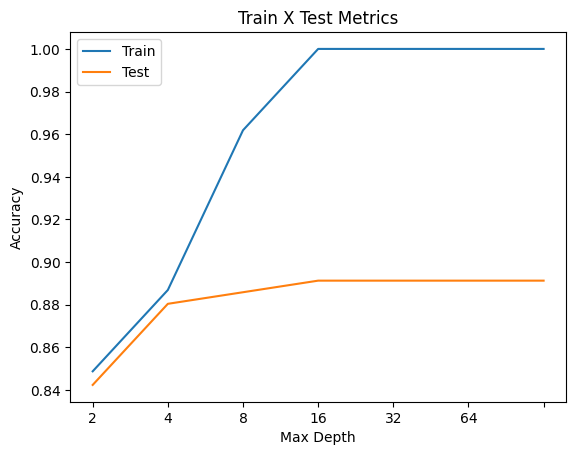

In [ ]:
# Tuning the min samples first

accuracy_list_train= []
accuracy_list_test = []

for max_depth in max_depth_list:
  # Fitting the model at the same time we can define it
  model = RandomForestClassifier(max_depth = max_depth,random_state=RANDOM_STATE).fit(x_train,y_train)

  predictions_train = model.predict(x_train)
  predictions_test = model.predict(x_test)
  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_test = accuracy_score(predictions_test,y_test)
  accuracy_list_train.append(accuracy_train)
  accuracy_list_test.append(accuracy_test)


plt.title("Train X Test Metrics")
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(ticks = range(len(max_depth_list)),labels = max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

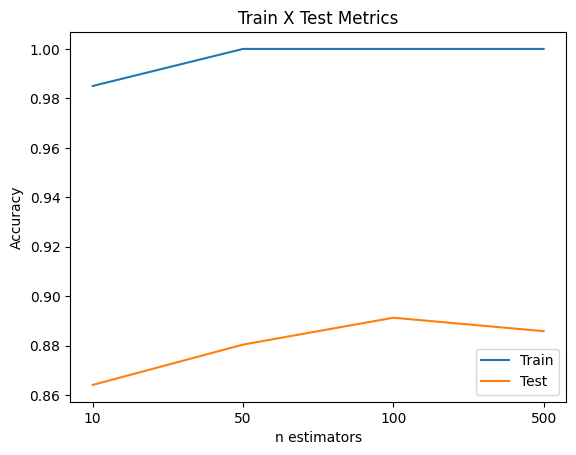

In [ ]:
# Tuning the min samples first

accuracy_list_train= []
accuracy_list_test = []

for n_estimators in n_estimators_list:
  # Fitting the model at the same time we can define it
  model = RandomForestClassifier(n_estimators= n_estimators,random_state=RANDOM_STATE).fit(x_train,y_train)

  predictions_train = model.predict(x_train)
  predictions_test = model.predict(x_test)
  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_test = accuracy_score(predictions_test,y_test)
  accuracy_list_train.append(accuracy_train)
  accuracy_list_test.append(accuracy_test)


plt.title("Train X Test Metrics")
plt.xlabel('n estimators')
plt.ylabel('Accuracy')
plt.xticks(ticks = range(len(n_estimators_list)),labels = n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

In [ ]:
# Hypertune the parameters

random_forest_model = RandomForestClassifier(n_estimators=100,
                                             max_depth=8,
                                             min_samples_split = 10).fit(x_train,y_train)



In [ ]:
print(f"Metrics train : \n\tAccuracy Score : {accuracy_score(random_forest_model.predict(x_train),y_train):.4f} \nMetrics Test : \n\tAccuracy Score : {accuracy_score(random_forest_model.predict(x_test),y_test):.4f}")

Metrics train : 
	Accuracy Score : 0.9223 
Metrics Test : 
	Accuracy Score : 0.8859


In [ ]:
# XGBoost

n = int(len(x_train)*0.8)

x_train_fit, x_train_eval, y_train_fit, y_train_eval = x_train[:n], x_train[n:], y_train[:n], y_train[n:]

In [ ]:
# 1. Pass early_stopping_rounds inside the constructor
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    verbosity=1,
    random_state=RANDOM_STATE,
    early_stopping_rounds=50  # <-- Moved here
)

# 2. Keep the fit method clean
xgb_model.fit(
    x_train_fit,
    y_train_fit,
    eval_set=[(x_train_eval, y_train_eval)]
)


[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435
[28]	validation_0-logloss:0.45316
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_model.best_iteration

17

In [ ]:
print(f"Metrics train : \n\tAccuracy Score : {accuracy_score(xgb_model.predict(x_train),y_train):.4f} \nMetrics Test : \n\tAccuracy Score : {accuracy_score(xgb_model.predict(x_test),y_test):.4f}")

Metrics train : 
	Accuracy Score : 0.9319 
Metrics Test : 
	Accuracy Score : 0.8533
